In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

In [ ]:
df = pd.read_csv("football_prediction_synthetic_dataset_5000.csv")
df.head(10)

,home_form,away_form,home_xg,away_xg,home_xga,away_xga,home_xt,away_xt,home_sot,away_sot,...,home_squad_chemistry,away_squad_chemistry,home_travel_fatigue,away_travel_fatigue,home_elo,away_elo,neutral_venue,competition_importance,weather_index,target
0,0.46,0.66,1.46,1.04,2.68,1.85,2.86,3.78,3.4,4.3,...,4.47,3.02,1.44,2.42,1996,2019,0,1,2.84,1
1,0.76,0.66,2.92,1.97,0.34,2.02,3.90,2.80,6.3,6.4,...,1.89,1.16,2.65,3.30,1628,1562,1,3,4.32,2
2,0.47,0.64,3.73,2.66,2.38,1.08,2.94,3.80,6.5,2.9,...,4.19,1.92,3.81,2.32,1523,1732,1,3,0.30,2
3,0.13,0.47,0.74,3.07,2.01,1.39,2.69,2.85,5.9,2.3,...,4.02,1.21,2.42,1.47,1995,1796,1,4,2.82,0
4,0.14,0.81,1.20,0.23,3.49,1.05,2.67,2.73,2.6,1.4,...,1.81,4.25,1.82,4.68,1971,1935,1,1,2.64,1
5,0.36,0.17,2.52,2.54,2.67,3.10,2.27,2.44,3.6,1.5,...,1.22,1.23,2.47,3.13,1889,1432,1,1,1.82,2
6,0.33,0.15,2.48,2.10,0.53,1.91,2.89,4.16,7.3,2.5,...,4.03,3.33,2.50,3.48,1804,1478,0,1,2.28,1
7,0.50,0.77,2.62,3.70,1.98,0.54,0.20,1.68,6.8,4.7,...,1.55,4.19,4.46,3.61,1670,1832,0,3,1.92,0
8,0.64,0.46,0.34,3.78,2.55,2.46,2.64,0.25,2.3,1.2,...,4.99,4.61,1.08,1.38,2050,1872,1,3,3.10,1
9,0.21,0.63,1.45,2.91,2.22,2.95,2.49,4.44,4.2,5.1,...,4.11,2.44,4.50,2.74,1740,1909,0,3,3.42,1


In [ ]:
df.columns

Index(['home_form', 'away_form', 'home_xg', 'away_xg', 'home_xga', 'away_xga',
       'home_xt', 'away_xt', 'home_sot', 'away_sot', 'home_attack_strength',
       'away_attack_strength', 'home_defense_strength',
       'away_defense_strength', 'home_rest_days', 'away_rest_days',
       'home_missing_players', 'away_missing_players',
       'home_average_possession', 'away_average_possession',
       'home_clean_sheet_rate', 'away_clean_sheet_rate',
       'home_head_to_head_rate', 'away_head_to_head_rate', 'referee_card_rate',
       'home_goalkeeper_rating', 'away_goalkeeper_rating',
       'home_finishing_efficiency', 'away_finishing_efficiency',
       'home_penalty_rating', 'away_penalty_rating', 'home_set_piece_strength',
       'away_set_piece_strength', 'home_press_resistance',
       'away_press_resistance', 'home_squad_chemistry', 'away_squad_chemistry',
       'home_travel_fatigue', 'away_travel_fatigue', 'home_elo', 'away_elo',
       'neutral_venue', 'competition_importance

In [ ]:
df['target'].value_counts()

target
0    2025
2    1972
1    1003
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   home_form                  5000 non-null   float64
 1   away_form                  5000 non-null   float64
 2   home_xg                    5000 non-null   float64
 3   away_xg                    5000 non-null   float64
 4   home_xga                   5000 non-null   float64
 5   away_xga                   5000 non-null   float64
 6   home_xt                    5000 non-null   float64
 7   away_xt                    5000 non-null   float64
 8   home_sot                   5000 non-null   float64
 9   away_sot                   5000 non-null   float64
 10  home_attack_strength       5000 non-null   float64
 11  away_attack_strength       5000 non-null   float64
 12  home_defense_strength      5000 non-null   float64
 13  away_defense_strength      5000 non-null   float64
 14  hom

In [ ]:
# 1. Define your threshold value here
threshold = 0.1

# 2. Correlate everything against actual_result specifically
target_corr = df.corr(numeric_only=True)["target"]

# 3. Drop the target's correlation with itself (always 1.0)
target_corr = target_corr.drop("target")

# 4. Filter for absolute correlation above threshold (catches strong negative too)
high_corr_with_target = target_corr[target_corr.abs() > threshold].sort_values(ascending=False)

print(high_corr_with_target)

home_attack_strength         0.276274
home_finishing_efficiency    0.250760
home_defense_strength        0.249302
home_goalkeeper_rating       0.240920
home_xg                      0.232317
away_xga                     0.220265
home_xga                    -0.209405
away_xg                     -0.236248
away_attack_strength        -0.253032
away_goalkeeper_rating      -0.260811
away_finishing_efficiency   -0.267878
away_defense_strength       -0.271113
Name: target, dtype: float64


In [ ]:
x = df.drop(['home_elo', 'away_elo', 'neutral_venue', 'weather_index', 'target'], axis=1).values
y = df['target'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=24, stratify=y)

In [ ]:
# Create the model
Football_Model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,

    # Hyperparameters
    n_estimators=2000,
    learning_rate=0.04,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.80,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2.0,

    # Performance
    tree_method="hist",
    eval_metric="mlogloss",

    # Other settings
    random_state=42,
    n_jobs=-1
)

# Train the model
Football_Model.fit(x_train, y_train)

# Predictions
y_pred = Football_Model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8380

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       405
           1       0.63      0.46      0.53       201
           2       0.87      0.92      0.89       394

    accuracy                           0.84      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.83      0.84      0.83      1000


Confusion Matrix:
[[384  21   0]
 [ 56  93  52]
 [  0  33 361]]


In [ ]:
importance = pd.DataFrame({
    "Feature": df.drop(['home_elo', 'away_elo', 'neutral_venue', 'weather_index', 'target'], axis=1).columns,
    "Importance": Football_Model.feature_importances_
})
print(importance.sort_values("Importance", ascending=False))

                      Feature  Importance
10       home_attack_strength    0.046693
28  away_finishing_efficiency    0.045608
13      away_defense_strength    0.044751
12      home_defense_strength    0.044294
26     away_goalkeeper_rating    0.043839
11       away_attack_strength    0.043022
27  home_finishing_efficiency    0.042721
3                     away_xg    0.042224
2                     home_xg    0.041428
25     home_goalkeeper_rating    0.041255
5                    away_xga    0.038717
4                    home_xga    0.037116
9                    away_sot    0.019712
34      away_press_resistance    0.019704
36       away_squad_chemistry    0.019604
14             home_rest_days    0.019253
7                     away_xt    0.019028
19    away_average_possession    0.018988
0                   home_form    0.018945
21      away_clean_sheet_rate    0.018764
1                   away_form    0.018654
30        away_penalty_rating    0.018511
32    away_set_piece_strength    0

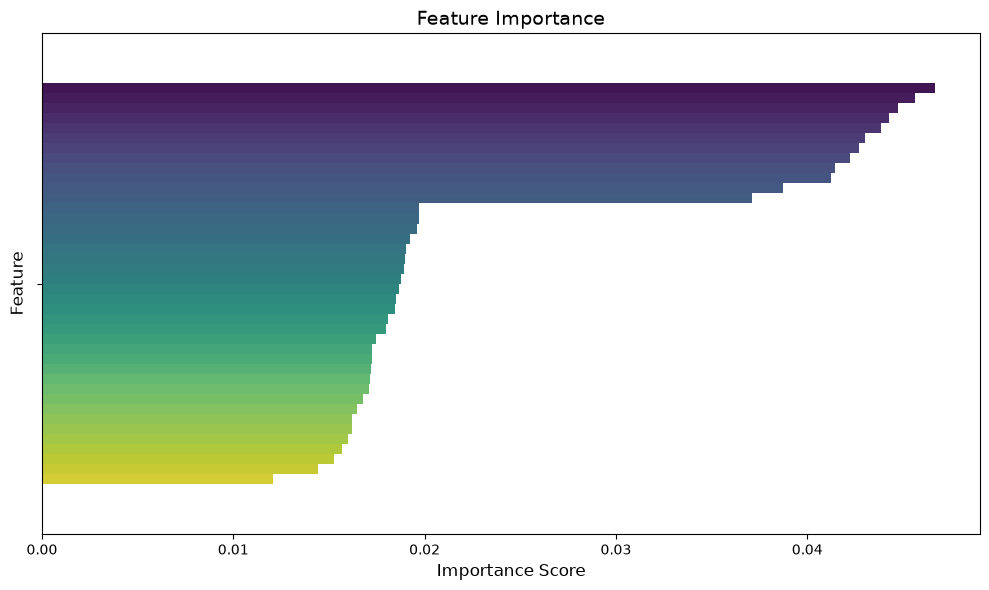

In [ ]:

plt.figure(figsize=(10, 6)) # Adjust width and height
sns.barplot(
    x="Importance", hue= "Feature", legend=False,
    data=importance.sort_values("Importance", ascending=False),
    palette="viridis" # Optional: add a color map
)
plt.title("Feature Importance", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout() # Prevents labels from getting cut off
plt.show()


In [ ]:
joblib.dump(Football_Model, "football_prediction_model.pkl")

['football_prediction_model.pkl']

In [ ]:


#Load the trained model
model = joblib.load("football_prediction_model.pkl")

# Create a single match with your engineered features
match_data = {
    "home_form": 1.0,
    "away_form": 1.0,
    "home_xg": 2.0,
    "away_xg": 2.75,
    "home_xga": 0.25,
    "away_xga": 1.50,
    "home_xt": 3.88,
    "away_xt": 3.58,
    "home_sot": 10.0,
    "away_sot": 9.50,
    "home_attack_strength": 0.69,
    "away_attack_strength": 0.94,
    "home_defense_strength": 0.17,
    "away_defense_strength": 1.03,
    "home_rest_days": 4,
    "away_rest_days": 3,
    "home_missing_players": 0,
    "away_missing_players": 0,
    "home_average_possession": 61.2,
    "away_average_possession": 53.5,
    "home_clean_sheet_rate": 0.75,
    "away_clean_sheet_rate": 0.0,
    "home_head_to_head_rate": 0.75,
    "away_head_to_head_rate": 0.25,
    "referee_card_rate": 4.0,
    "home_goalkeeper_rating": 2.65,
    "away_goalkeeper_rating": 1.74,
    "home_finishing_efficiency": 2.0,
    "away_finishing_efficiency": 2.9,
    "home_penalty_rating": 3.63,
    "away_penalty_rating": 1.73,
    "home_set_piece_strength": 1.32,
    "away_set_piece_strength": 4.17,
    "home_press_resistance": 3.74,
    "away_press_resistance": 3.56,
    "home_squad_chemistry": 5.0,
    "away_squad_chemistry": 5.0,
    "home_travel_fatigue": 0,
    "away_travel_fatigue": 0,
    "competition_importance": 5,
}

# Convert to DataFrame
X = pd.DataFrame([match_data])

# Make prediction
prediction = model.predict(X)[0]

# Prediction probabilities
probabilities =  model.predict_proba(X)[0]

classes =  model.classes_

print("Prediction:", prediction)
print()

print("Probabilities")
for cls, prob in zip(classes, probabilities):
    print(f"{cls}: {prob:.2%}")

Prediction: 2

Probabilities
0: 1.40%
1: 5.13%
2: 93.48%
